# Bee regional classification from wing patterns — superpixel graphs + GNN

This version does **not** use skeletonization. Instead of tracing the vein network into a
1-pixel-wide centerline, each wing is broken into **superpixels** (small, roughly uniform
patches produced by SLIC) and a graph is built directly from those patches: each superpixel is
a node, and two superpixels that touch each other in the image become an edge. The GNN then
learns which arrangement of patch shapes, shades, and adjacencies is characteristic of each
region — it is not told where the veins are at all, and has to discover pattern from whichever
patch statistics (colour, shape, layout) turn out to be predictive.

**Why drop skeletonization.** Skeletonization is a topological operation: it needs a very
clean binary vein mask, and it amplifies small mask defects into broken or spurious branches.
Superpixel segmentation (SLIC) has no such brittle step — it works directly on the greyscale
image and degrades gracefully when veins are faint, blurry, or partly occluded. The trade-off
is that you lose the explicit vein-junction/vein-segment structure and the model has to find
useful pattern in patch statistics instead. Which approach wins is an empirical question for
your actual images — this notebook is a fully independent, working way to test the superpixel
side of that question.

**Size/ratio invariance, differently this time.** SLIC's `n_segments` parameter targets a
*count* of segments, not a pixel resolution, so a 400×300 image and a 2000×700 image both come
out with (approximately) the same number of superpixels. Node coordinates are then centred and
scaled exactly as before (isotropically, so aspect ratio survives) and each node's area is
stored as a *fraction of the wing's foreground area*, which is naturally resolution-free.

**What's still shared with the skeleton approach.** The GNN architecture, training loop,
augmentation strategy, and evaluation protocol are unchanged — only the image→graph step
differs. Node/edge feature counts are kept at 8/5 on purpose so the two notebooks are a fair,
like-for-like architecture comparison; only the *source of the graph* changes.

**Run order:** cells 1–6 build and QC the extractor (no torch needed) → cell 7 picks demo or
real data → cells 8–14 build the dataset, train, evaluate, predict.

## 0. Install

In [1]:
# !pip install numpy opencv-python scikit-image scipy scikit-learn matplotlib
# !pip install torch --index-url https://download.pytorch.org/whl/cu121
# !pip install torch_geometric

import importlib
for m in ["cv2", "skimage", "scipy", "sklearn", "matplotlib", "torch", "torch_geometric"]:
    try:
        mod = importlib.import_module(m)
        print(f"{m:18s} {getattr(mod, '__version__', 'ok')}")
    except ImportError:
        print(f"{m:18s} MISSING")

cv2                5.0.0
skimage            0.26.0
scipy              1.18.1
sklearn            1.9.0
matplotlib         3.11.2
torch              2.14.0+cpu


C:\Users\Amine\.conda\envs\studenv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


torch_geometric    2.8.0.post1


## 1. Imports and configuration

In [2]:
import json, math, os, random, shutil, time, copy
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.segmentation import slic, mark_boundaries
from skimage.measure import regionprops

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- feature layout: identical dimensionality to the skeleton-based notebook,
# so the two are a fair architecture comparison; only the graph SOURCE differs.
NODE_FEATURES = ["x", "y", "r", "area_frac", "mean_intensity", "std_intensity",
                 "eccentricity", "solidity"]
EDGE_FEATURES = ["centroid_dist", "boundary_strength", "intensity_diff", "cos2t", "sin2t"]
NODE_DIM, EDGE_DIM = len(NODE_FEATURES), len(EDGE_FEATURES)
IDX_XY, IDX_R = (0, 1), 2


class ExtractionError(RuntimeError):
    pass


@dataclass
class ExtractConfig:
    # preprocessing
    max_side: int = 1024          # longest side after isotropic downscale
    # foreground (wing silhouette) detection
    fg_blur: int = 5
    fg_close_k: int = 15          # morphological close kernel, bridges thin gaps
    fg_min_frac: float = 0.03     # reject masks covering too little of the frame
    fg_max_frac: float = 0.97     # reject masks covering almost the whole frame
    # SLIC superpixels
    n_segments: int = 120         # target patch COUNT, not pixel size -> size/ratio invariant
    compactness: float = 12.0     # higher = more square/regular patches, less shape-hugging
    slic_sigma: float = 1.0
    min_overlap_frac: float = 0.5  # used only on skimage versions without slic(mask=...)
    # graph construction
    min_nodes: int = 20
    max_nodes: int = 400
    pca_align: bool = True        # rotation / reflection invariance

    def to_dict(self):
        return asdict(self)


CFG = ExtractConfig()
print(CFG)

ExtractConfig(max_side=1024, fg_blur=5, fg_close_k=15, fg_min_frac=0.03, fg_max_frac=0.97, n_segments=120, compactness=12.0, slic_sigma=1.0, min_overlap_frac=0.5, min_nodes=20, max_nodes=400, pca_align=True)


## 2. Foreground (wing silhouette) mask

Superpixels should tile the *wing*, not the background of the photo. This step finds the wing
silhouette so SLIC can be restricted to it. It works by Otsu-thresholding the image both ways
and keeping whichever candidate's largest blob touches the image border the *least* — in a
typical specimen photo the background is the region touching all four edges, and the wing is
the blob sitting inside it. Adjust `fg_close_k` if the wing outline comes out with holes or
ragged edges.

In [3]:
def load_gray(path, max_side=1024):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ExtractionError(f"cannot read image: {path}")
    h, w = img.shape
    s = max_side / float(max(h, w))
    if s < 1.0:                      # only ever downscale, aspect ratio preserved
        img = cv2.resize(img, (max(1, round(w * s)), max(1, round(h * s))),
                         interpolation=cv2.INTER_AREA)
    return img


def foreground_mask(gray, cfg=CFG):
    g = cv2.GaussianBlur(gray, (cfg.fg_blur | 1, cfg.fg_blur | 1), 0)
    t, _ = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    best, best_border = None, np.inf
    for cand in (g > t, g <= t):
        lab, n = ndi.label(cand, structure=np.ones((3, 3), int))
        if n == 0:
            continue
        sizes = np.bincount(lab.ravel()); sizes[0] = 0
        cc = lab == sizes.argmax()
        border = (cc[0, :].sum() + cc[-1, :].sum() + cc[:, 0].sum() + cc[:, -1].sum())
        border_frac = border / (2 * (cc.shape[0] + cc.shape[1]))
        if border_frac < best_border:
            best_border, best = border_frac, cc

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (cfg.fg_close_k, cfg.fg_close_k))
    mask = cv2.morphologyEx(best.astype(np.uint8), cv2.MORPH_CLOSE, k) > 0
    mask = ndi.binary_fill_holes(mask)
    lab, n = ndi.label(mask, structure=np.ones((3, 3), int))
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    mask = lab == sizes.argmax()

    frac = mask.mean()
    if frac < cfg.fg_min_frac or frac > cfg.fg_max_frac:
        raise ExtractionError(f"foreground mask covers {frac:.1%} of the frame "
                              f"(expected between {cfg.fg_min_frac:.0%} and "
                              f"{cfg.fg_max_frac:.0%}) - check lighting/background contrast")
    return mask

## 3. Superpixels + region-adjacency graph

`slic(..., mask=fg_mask)` restricts segmentation to the wing silhouette directly when the
installed skimage supports it (0.19+); older versions fall back to segmenting the whole image
and then discarding any superpixel that doesn't mostly overlap the mask. Either way you get
roughly `n_segments` patches confined to the wing, regardless of the photo's size or aspect
ratio.

Adjacency is computed by scanning horizontal and vertical neighbour pixels for label changes —
this needs no extra library and works identically across skimage versions. The number of
shared border pixels per adjacent pair becomes the edge's `boundary_strength` feature.

In [4]:
def superpixel_labels(gray, mask, cfg=CFG):
    img = gray.astype(np.float64)
    try:
        labels = slic(img, n_segments=cfg.n_segments, compactness=cfg.compactness,
                      sigma=cfg.slic_sigma, mask=mask, channel_axis=None,
                      start_label=1, enforce_connectivity=True)
        # pixels outside `mask` come back labelled 0
    except TypeError:
        labels = slic(img, n_segments=cfg.n_segments, compactness=cfg.compactness,
                      sigma=cfg.slic_sigma, channel_axis=None, start_label=1,
                      enforce_connectivity=True)
        keep = [i for i in np.unique(labels)
                if (labels[labels == i].size and
                    (mask[labels == i]).sum() / (labels == i).sum() >= cfg.min_overlap_frac)]
        remap = np.zeros(labels.max() + 1, dtype=labels.dtype)
        for new_id, old_id in enumerate(keep, start=1):
            remap[old_id] = new_id
        labels = remap[labels]
        labels[~mask] = 0
    return labels


def build_adjacency(labels):
    a, b = labels[:, :-1].ravel(), labels[:, 1:].ravel()          # horizontal neighbours
    m = (a != b) & (a > 0) & (b > 0)
    pa, pb = a[m], b[m]
    a2, b2 = labels[:-1, :].ravel(), labels[1:, :].ravel()         # vertical neighbours
    m2 = (a2 != b2) & (a2 > 0) & (b2 > 0)
    pa, pb = np.concatenate([pa, a2[m2]]), np.concatenate([pb, b2[m2]])
    if len(pa) == 0:
        raise ExtractionError("no adjacent superpixel pairs found")
    lo, hi = np.minimum(pa, pb), np.maximum(pa, pb)
    n = int(labels.max()) + 1
    keys = lo.astype(np.int64) * n + hi.astype(np.int64)
    uniq, counts = np.unique(keys, return_counts=True)
    edges = np.stack([uniq // n, uniq % n], axis=1)
    return edges, counts.astype(np.float64)

## 4. Node/edge features and normalisation

Same normalisation strategy as any coordinate-based graph: centroids are centred and divided
by RMS radius **isotropically** (so aspect ratio survives, resolution doesn't), then optionally
PCA-aligned so a wing mounted at an angle lands in the same frame as one mounted straight.

`area_frac` divides each superpixel's pixel count by the *foreground* mask's total area, not
the whole image — that makes it resolution-free without needing to know the original photo's
scale. `eccentricity` and `solidity` are shape descriptors regionprops gives for free (how
elongated a patch is, how much it deviates from convex) and pick up patch shapes that follow
the venation without ever looking for veins explicitly.

In [5]:
def _mean_intensity(prop):                     # skimage renamed this attribute in 0.26
    v = getattr(prop, "intensity_mean", None)
    return float(v) if v is not None else float(prop.mean_intensity)


def _normalise(xy, pca_align):
    xy = xy - xy.mean(0, keepdims=True)
    scale = np.sqrt((xy ** 2).sum(1).mean())
    if scale < 1e-8:
        raise ExtractionError("degenerate node cloud")
    xy = xy / scale
    if pca_align:
        w, v = np.linalg.eigh(np.cov(xy.T))
        xy = xy @ v[:, np.argsort(w)[::-1]]
        for k in range(2):                      # deterministic sign fix
            if (xy[:, k] ** 3).sum() < 0:
                xy[:, k] *= -1.0
    return xy


def build_features(gray, labels, mask, cfg=CFG):
    props = regionprops(labels, intensity_image=gray)
    n = len(props)
    if n < cfg.min_nodes:
        raise ExtractionError(f"only {n} superpixels kept (min_nodes={cfg.min_nodes})")
    if n > cfg.max_nodes:
        raise ExtractionError(f"{n} superpixels exceeds max_nodes")

    ids = [p.label for p in props]
    cy = np.array([p.centroid[0] for p in props])
    cx = np.array([p.centroid[1] for p in props])
    area = np.array([p.area for p in props], float)
    mean_i = np.array([_mean_intensity(p) for p in props]) / 255.0
    ecc = np.array([p.eccentricity for p in props])
    sol = np.array([p.solidity for p in props])
    std_i = ndi.standard_deviation(gray, labels, index=ids) / 255.0

    xy = _normalise(np.stack([cx, cy], 1), cfg.pca_align)
    area_frac = area / max(mask.sum(), 1)

    edges, counts = build_adjacency(labels)
    edges0 = edges - 1                          # labels are 1..n contiguous -> zero-based

    d = xy[edges0[:, 1]] - xy[edges0[:, 0]]
    cdist = np.linalg.norm(d, axis=1)
    theta = np.arctan2(d[:, 1], d[:, 0])
    bstrength = counts / max(counts.mean(), 1e-8)
    idiff = np.abs(mean_i[edges0[:, 1]] - mean_i[edges0[:, 0]])

    x = np.stack([xy[:, 0], xy[:, 1], np.linalg.norm(xy, axis=1), area_frac * 50,
                  mean_i, std_i, ecc, sol], 1).astype(np.float32)
    ef = np.stack([cdist, np.clip(bstrength, 0, 10), idiff,
                  np.cos(2 * theta), np.sin(2 * theta)], 1).astype(np.float32)
    edge_index = np.concatenate([edges0, edges0[:, ::-1]], 0).T.astype(np.int64)
    edge_attr = np.concatenate([ef, ef], 0).astype(np.float32)

    return x, edge_index, edge_attr, xy.astype(np.float32)


def image_to_graph(path, cfg=CFG):
    gray = load_gray(path, cfg.max_side)
    mask = foreground_mask(gray, cfg)
    labels = superpixel_labels(gray, mask, cfg)
    x, edge_index, edge_attr, pos = build_features(gray, labels, mask, cfg)
    return {"x": x, "edge_index": edge_index, "edge_attr": edge_attr, "pos": pos,
            "num_nodes": x.shape[0], "num_edges": edge_index.shape[1] // 2}

## 5. QC view — **look at this before you train anything**

Yellow lines are superpixel boundaries, cyan lines are the adjacency graph, red dots are patch
centroids. You want the boundaries to stay inside the wing and roughly the same *count* of
patches regardless of the photo's size.

| symptom | fix |
|---|---|
| mask includes background / excludes part of the wing | adjust `fg_close_k`, check lighting contrast between wing and background |
| very uneven patch sizes | raise `compactness` for more regular shapes, or lower it to hug edges more |
| too few / too many patches | change `n_segments` |
| mask covers almost nothing or almost everything (`ExtractionError`) | background/wing contrast is too low for Otsu — consider a manual mask or different lighting |

In [6]:
def show_extraction(path, cfg=CFG, figsize=(14, 5)):
    gray = load_gray(path, cfg.max_side)
    mask = foreground_mask(gray, cfg)
    labels = superpixel_labels(gray, mask, cfg)
    props = regionprops(labels, intensity_image=gray)
    cy = np.array([p.centroid[0] for p in props])
    cx = np.array([p.centroid[1] for p in props])
    edges, _ = build_adjacency(labels)

    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    vis = mark_boundaries(rgb, labels, color=(1, 1, 0), mode="thick")

    fig, ax = plt.subplots(1, 3, figsize=figsize)
    ax[0].imshow(gray, cmap="gray"); ax[0].set_title(f"input {gray.shape[1]}x{gray.shape[0]}")
    ax[1].imshow(mask, cmap="gray"); ax[1].set_title(f"foreground mask ({mask.mean():.0%})")
    ax[2].imshow(vis)
    for a, b in edges:
        ax[2].plot([cx[a - 1], cx[b - 1]], [cy[a - 1], cy[b - 1]],
                  "-", c="deepskyblue", lw=0.6, alpha=0.8)
    ax[2].scatter(cx, cy, s=10, c="red", zorder=3)
    ax[2].set_title(f"graph: {len(props)} nodes, {len(edges)} edges")
    for a_ in ax:
        a_.axis("off")
    plt.tight_layout(); plt.show()
    return len(props), len(edges)

## 6. Data

Same expected layout as always — folder name = class label, filenames and image dimensions
irrelevant:

```
data/
  region_A/  0001.jpg ... 0183.jpg
  region_B/  ...
  region_C/
  region_D/
  region_E/
```

Leave `USE_DEMO_DATA = True` to generate synthetic wings with an actual filled membrane
(distinct in shade from the background, the way a real specimen photo is) so the foreground
step has something real to find. Then set it to `False` and point `IMAGE_ROOT` at your data.

In [7]:
USE_DEMO_DATA = False             # <-- set False once you have your own data
IMAGE_ROOT    = "bees"
CACHE_ROOT    = "cache_sp"
DEMO_PER_CLASS = 40               # demo only; you have 183 real ones per class
DEMO_SIZES = [(800, 500), (1600, 900), (420, 320), (1100, 1100), (2000, 700)]


def _synth_wing(w, h, cls, seed):
    r = np.random.default_rng(seed)
    img = np.full((h, w), 245, np.uint8)                     # background
    cx, cy, ax_, ay = w // 2, h // 2, int(w * .40), int(h * .30)
    cv2.ellipse(img, (cx, cy), (ax_, ay), 0, 0, 360, 205, -1)  # filled wing membrane
    cv2.ellipse(img, (cx, cy), (ax_, ay), 0, 0, 360, 150, 2)
    n_long, slant = 6 + cls, 0.10 * cls                       # class-specific venation
    for i in range(n_long):
        t = -0.9 + 1.8 * i / max(1, n_long - 1)
        y1 = int(cy + ay * t * .8 + r.normal(0, 3))
        y2 = int(cy + ay * (t * .5 + slant) + r.normal(0, 3))
        cv2.line(img, (int(cx - ax_ * .85), y1), (int(cx + ax_ * .85), y2), 120, 2)
    for i in range(6):
        x = int(cx - ax_ * .7 + i * ax_ * .25)
        cv2.line(img, (x, int(cy - ay * .75)), (int(x + ax_ * .1), int(cy + ay * .75)), 120, 2)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return np.clip(img.astype(int) + r.normal(0, 4, img.shape), 0, 255).astype(np.uint8)


if USE_DEMO_DATA:
    shutil.rmtree(IMAGE_ROOT, ignore_errors=True)
    shutil.rmtree(CACHE_ROOT, ignore_errors=True)
    for c in range(5):
        d = Path(IMAGE_ROOT, f"region_{chr(65 + c)}"); d.mkdir(parents=True, exist_ok=True)
        for i in range(DEMO_PER_CLASS):
            w, h = DEMO_SIZES[i % len(DEMO_SIZES)]
            cv2.imwrite(str(d / f"s{i:03d}.png"), _synth_wing(w, h, c, c * 1000 + i))
    print(f"demo data written to {IMAGE_ROOT}/")

IMAGE_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}


def list_samples(root):
    root = Path(root)
    classes = sorted(d.name for d in root.iterdir() if d.is_dir() and not d.name.startswith("."))
    samples = [(str(f), ci) for ci, c in enumerate(classes)
               for f in sorted((root / c).iterdir()) if f.suffix.lower() in IMAGE_EXT]
    return classes, samples


CLASSES, SAMPLES = list_samples(IMAGE_ROOT)
print(f"{len(CLASSES)} classes: {CLASSES}")
print(f"{len(SAMPLES)} images  |  per class: {np.bincount([y for _, y in SAMPLES])}")

5 classes: ['Austria', 'Greece', 'Hungary', 'Moldova', 'Morocco']
915 images  |  per class: [183 183 183 183 183]


### QC a few images now

--- Austria : AT-0001-031-003678-L.dw.png


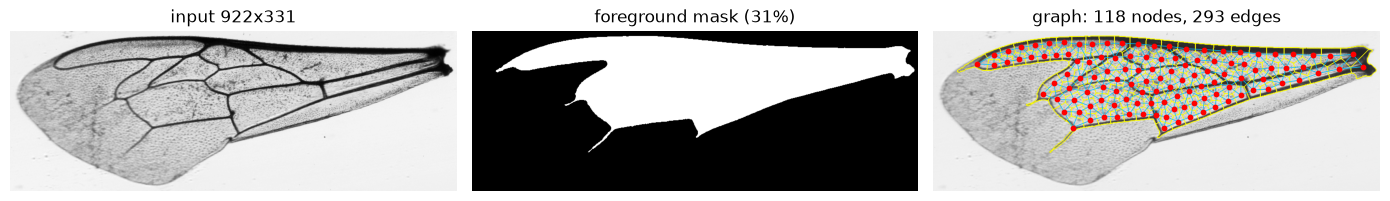

--- Greece : GR-0001-2004-AT-SA-01-1.dw.png


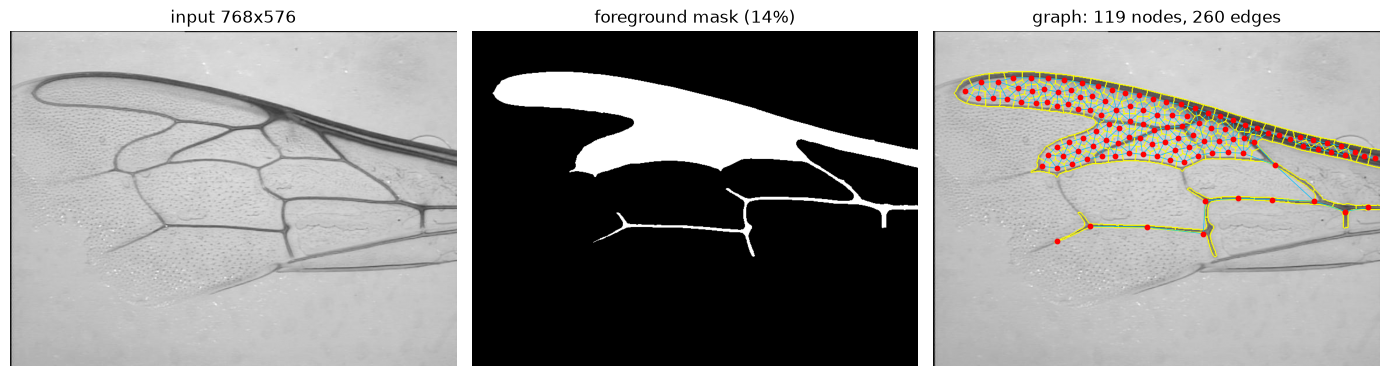

--- Hungary : HU-0001-2019-000001-L.dw.png


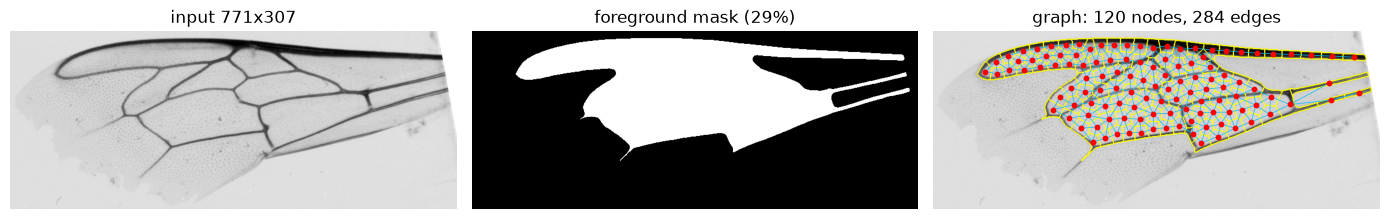

--- Moldova : MD-0001-2016-001989.dw.png


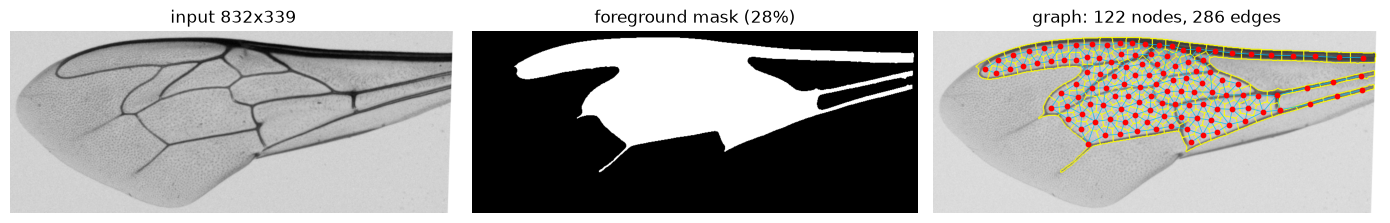

--- Morocco : MA-0125-TT01-000879-R.dw.png


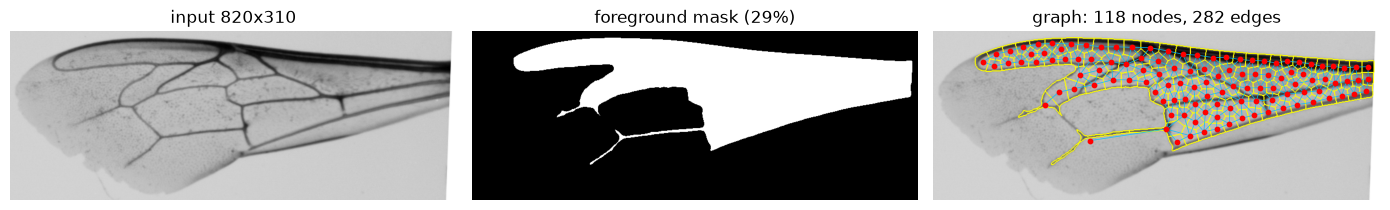

In [8]:
for cls_idx in range(len(CLASSES)):
    path = next(p for p, y in SAMPLES if y == cls_idx)
    print(f"--- {CLASSES[cls_idx]} : {Path(path).name}")
    show_extraction(path)

Node counts should land close to `n_segments` for every class regardless of image size — that
is the size/ratio invariance working. If one class systematically yields far fewer patches
(often because `foreground_mask` failed on that class's lighting), fix it here rather than let
the model learn "bad segmentation = region C".

In [9]:
rows = []
for cls_idx, cname in enumerate(CLASSES):
    ns = []
    for p, y in [s for s in SAMPLES if s[1] == cls_idx][:8]:
        try:
            ns.append(image_to_graph(p)["num_nodes"])
        except ExtractionError as e:
            print(f"  FAIL {Path(p).name}: {e}")
    if ns:
        rows.append((cname, len(ns), min(ns), float(np.mean(ns)), max(ns)))

print(f"{'class':<12}{'n':>4}{'min':>7}{'mean':>8}{'max':>7}")
for r in rows:
    print(f"{r[0]:<12}{r[1]:>4}{r[2]:>7}{r[3]:>8.1f}{r[4]:>7}")

class          n    min    mean    max
Austria        8    114   116.5    119
Greece         8    111   114.8    119
Hungary        8    114   117.4    120
Moldova        8    114   118.0    122
Morocco        8    112   116.0    121


## 7. Build the PyG dataset

Extraction is the slow part, cached in `cache_sp/processed/`. If more than ~5% of images fail,
go back to cell 5 and fix `foreground_mask`/`n_segments` rather than train on a biased subset.

> **Delete `cache_sp/processed/` whenever you change `ExtractConfig` or add a class folder.**

In [10]:
import torch
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


class WingGraphDataset(InMemoryDataset):
    def __init__(self, root, image_root=None, cfg=CFG, transform=None):
        self.image_root, self.cfg = image_root, cfg
        super().__init__(root, transform)
        if hasattr(self, "load"):
            self.load(self.processed_paths[0])          # PyG >= 2.4
        else:
            self.data, self.slices = torch.load(self.processed_paths[0])
        meta = json.loads(Path(self.processed_dir, "meta.json").read_text())
        self.classes, self.failures = meta["classes"], meta["failures"]
        self.paths = meta["paths"]

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ["wings.pt", "meta.json"]

    def process(self):
        classes, samples = list_samples(self.image_root)
        data_list, failures, kept = [], [], []
        for i, (path, label) in enumerate(samples, 1):
            try:
                g = image_to_graph(path, self.cfg)
            except Exception as e:
                failures.append({"path": path, "error": f"{type(e).__name__}: {e}"})
                continue
            d = Data(x=torch.from_numpy(g["x"]),
                     edge_index=torch.from_numpy(g["edge_index"]),
                     edge_attr=torch.from_numpy(g["edge_attr"]),
                     pos=torch.from_numpy(g["pos"]),
                     y=torch.tensor([label], dtype=torch.long))
            data_list.append(d); kept.append(path)
            if i % 50 == 0:
                print(f"  [{i}/{len(samples)}]", flush=True)

        print(f"kept {len(data_list)}, failed {len(failures)} "
              f"({100 * len(failures) / max(1, len(samples)):.1f}%)")
        for f in failures[:5]:
            print("   ", Path(f["path"]).name, "->", f["error"])
        if not data_list:
            raise RuntimeError("every image failed extraction - revisit cell 5")

        os.makedirs(self.processed_dir, exist_ok=True)
        Path(self.processed_dir, "meta.json").write_text(json.dumps(
            {"classes": classes, "cfg": self.cfg.to_dict(), "failures": failures,
             "paths": kept}, indent=2))
        if hasattr(self, "save"):
            self.save(data_list, self.processed_paths[0])
        else:
            torch.save(self.collate(data_list), self.processed_paths[0])


t0 = time.time()
dataset = WingGraphDataset(CACHE_ROOT, IMAGE_ROOT, CFG)
NUM_CLASSES = len(dataset.classes)          # <-- never hard-coded
y_all = torch.cat([dataset[i].y for i in range(len(dataset))]).numpy()
ns = [dataset[i].num_nodes for i in range(len(dataset))]
print(f"\n{len(dataset)} graphs / {NUM_CLASSES} classes in {time.time() - t0:.1f}s")
print("per-class:", np.bincount(y_all, minlength=NUM_CLASSES))
print(f"nodes min/mean/max: {min(ns)}/{np.mean(ns):.1f}/{max(ns)}")
print(dataset[0])

device: cpu


Processing...


  [50/915]
  [100/915]
  [150/915]


C:\Users\Amine\.conda\envs\studenv\Lib\site-packages\scipy\_lib\_util.py:306: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


  [200/915]
  [250/915]
  [300/915]
  [350/915]
  [400/915]
  [450/915]
  [500/915]
  [550/915]
  [600/915]
  [650/915]
  [700/915]
  [750/915]
  [800/915]
  [850/915]
  [900/915]
kept 915, failed 0 (0.0%)

915 graphs / 5 classes in 366.1s
per-class: [183 183 183 183 183]
nodes min/mean/max: 105/116.9/122
Data(x=[118, 8], edge_index=[2, 586], edge_attr=[586, 5], y=[1], pos=[118, 2])


Done!


## 8. Augmentation

Same rationale as before: with a few hundred graphs a GNN will memorise the training set, so
this matters more than architecture tweaks. `RandomIntensityShift` is new here and specific to
superpixel features — it perturbs the mean/std intensity features slightly, simulating
lighting variation between photography sessions, which the skeleton-based graph didn't have a
direct analogue for.

In [11]:
from torch_geometric.transforms import BaseTransform, Compose


class RandomRotate2D(BaseTransform):
    def __init__(self, max_deg=15.0):
        self.max_rad = math.radians(max_deg)
    def forward(self, data):
        t = (torch.rand(1).item() * 2 - 1) * self.max_rad
        c, s = math.cos(t), math.sin(t)
        R = torch.tensor([[c, -s], [s, c]], dtype=data.x.dtype)
        data.x[:, 0:2] = data.x[:, 0:2] @ R.T
        if getattr(data, "pos", None) is not None:
            data.pos = data.pos @ R.T
        if data.edge_attr is not None and data.edge_attr.numel():
            cos2, sin2 = data.edge_attr[:, 3].clone(), data.edge_attr[:, 4].clone()
            c2, s2 = math.cos(2 * t), math.sin(2 * t)
            data.edge_attr[:, 3] = cos2 * c2 - sin2 * s2
            data.edge_attr[:, 4] = cos2 * s2 + sin2 * c2
        return data


class RandomScale(BaseTransform):
    def __init__(self, lo=0.92, hi=1.08):
        self.lo, self.hi = lo, hi
    def forward(self, data):
        s = self.lo + torch.rand(1).item() * (self.hi - self.lo)
        data.x[:, 0:2] *= s; data.x[:, IDX_R] *= s
        if getattr(data, "pos", None) is not None:
            data.pos = data.pos * s
        return data


class JitterPositions(BaseTransform):
    def __init__(self, sigma=0.02):
        self.sigma = sigma
    def forward(self, data):
        data.x[:, 0:2] += torch.randn(data.num_nodes, 2, dtype=data.x.dtype) * self.sigma
        data.x[:, IDX_R] = data.x[:, 0:2].norm(dim=1)
        return data


class RandomIntensityShift(BaseTransform):
    # Simulates lighting/exposure differences between photography sessions.
    def __init__(self, sigma=0.05):
        self.sigma = sigma
    def forward(self, data):
        shift = torch.randn(1).item() * self.sigma
        data.x[:, 4] = (data.x[:, 4] + shift).clamp(0, 1)          # mean_intensity
        if data.edge_attr is not None:
            pass                                                    # intensity_diff untouched
        return data


class RandomEdgeDrop(BaseTransform):
    def __init__(self, p=0.08):
        self.p = p
    def forward(self, data):
        E = data.edge_index.size(1) // 2
        if E < 4:
            return data
        keep = torch.rand(E) > self.p
        if keep.sum() < 2:
            return data
        k2 = torch.cat([keep, keep])
        data.edge_index = data.edge_index[:, k2]
        if data.edge_attr is not None:
            data.edge_attr = data.edge_attr[k2]
        return data


class RandomNodeDrop(BaseTransform):
    def __init__(self, p=0.05):
        self.p = p
    def forward(self, data):
        n = data.num_nodes
        if n < 15:
            return data
        keep = torch.rand(n) > self.p
        if keep.sum() < 10:
            return data
        idx = torch.nonzero(keep).view(-1)
        remap = -torch.ones(n, dtype=torch.long); remap[idx] = torch.arange(idx.numel())
        ei = data.edge_index
        m = keep[ei[0]] & keep[ei[1]]
        data.edge_index = remap[ei[:, m]]
        if data.edge_attr is not None:
            data.edge_attr = data.edge_attr[m]
        data.x = data.x[idx]
        if getattr(data, "pos", None) is not None:
            data.pos = data.pos[idx]
        return data


class FeatureNoise(BaseTransform):
    def __init__(self, sigma=0.02):
        self.sigma = sigma
    def forward(self, data):
        data.x = data.x + torch.randn_like(data.x) * self.sigma
        if data.edge_attr is not None:
            data.edge_attr = data.edge_attr + torch.randn_like(data.edge_attr) * self.sigma
        return data


TRAIN_TF = Compose([RandomRotate2D(15), RandomScale(), JitterPositions(0.02),
                    RandomIntensityShift(0.05), RandomEdgeDrop(0.08),
                    RandomNodeDrop(0.05), FeatureNoise(0.02)])

_d = TRAIN_TF(dataset[0].clone())
print("augmented sample:", _d.num_nodes, "nodes,", _d.edge_index.size(1) // 2, "edges")

augmented sample: 109 nodes, 233 edges


## 9. The model

Unchanged from the skeleton-based version: `GINEConv` (consumes edge features directly),
residual connections, BatchNorm, JumpingKnowledge, mean+max pooling readout. Keeping the
architecture identical is deliberate — it isolates the image→graph choice as the only variable
if you want to compare this notebook against the skeleton one on the same data.

In [12]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import (GATv2Conv, GINEConv, JumpingKnowledge,
                                global_max_pool, global_mean_pool)


def _mlp(i, h, o):
    return nn.Sequential(nn.Linear(i, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Linear(h, o))


class WingGNN(nn.Module):
    def __init__(self, num_classes, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden=128,
                 layers=4, dropout=0.3, conv="gine", heads=4):
        super().__init__()
        self.hparams = dict(num_classes=num_classes, node_dim=node_dim, edge_dim=edge_dim,
                            hidden=hidden, layers=layers, dropout=dropout, conv=conv,
                            heads=heads)
        self.dropout = dropout
        self.node_enc = nn.Sequential(nn.Linear(node_dim, hidden), nn.ReLU(),
                                      nn.Linear(hidden, hidden))
        self.edge_enc = nn.Sequential(nn.Linear(edge_dim, hidden), nn.ReLU(),
                                      nn.Linear(hidden, hidden))
        self.convs, self.norms = nn.ModuleList(), nn.ModuleList()
        for _ in range(layers):
            self.convs.append(
                GINEConv(_mlp(hidden, hidden, hidden), train_eps=True, edge_dim=hidden)
                if conv == "gine" else
                GATv2Conv(hidden, hidden // heads, heads=heads, edge_dim=hidden,
                          dropout=dropout))
            self.norms.append(nn.BatchNorm1d(hidden))
        self.jk = JumpingKnowledge("cat")
        self.head = nn.Sequential(
            nn.Linear(hidden * layers * 2, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes))

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        h, e = self.node_enc(x), self.edge_enc(ea)
        hs = []
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h = F.dropout(F.relu(norm(conv(h, ei, e))), self.dropout, self.training) + h_in
            hs.append(h)
        h = self.jk(hs)
        g = torch.cat([global_mean_pool(h, batch), global_max_pool(h, batch)], 1)
        return self.head(g)


_m = WingGNN(NUM_CLASSES)
print(f"{sum(p.numel() for p in _m.parameters()):,} parameters, {NUM_CLASSES} classes")

375,177 parameters, 5 classes


## 10. Train

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split

EPOCHS, BATCH_SIZE, LR, WEIGHT_DECAY = 200, 32, 3e-3, 1e-4
HIDDEN, LAYERS, DROPOUT, CONV = 128, 4, 0.3, "gine"
PATIENCE, LABEL_SMOOTHING = 40, 0.05


def subset(indices, transform):
    sub = dataset[torch.as_tensor(np.asarray(indices), dtype=torch.long)]
    sub.transform = transform
    return sub


def run_epoch(model, loader, opt=None, class_weight=None):
    train = opt is not None
    model.train(train)
    tot, preds, trues = 0.0, [], []
    for b in loader:
        b = b.to(DEVICE)
        with torch.set_grad_enabled(train):
            out = model(b)
            loss = F.cross_entropy(out, b.y, weight=class_weight,
                                   label_smoothing=LABEL_SMOOTHING if train else 0.0)
        if train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
        tot += float(loss) * b.num_graphs
        preds.append(out.argmax(1).cpu()); trues.append(b.y.cpu())
    p, t = torch.cat(preds).numpy(), torch.cat(trues).numpy()
    return tot / len(t), (p == t).mean(), f1_score(t, p, average="macro"), p, t


def fit(tr_idx, va_idx, epochs=EPOCHS, verbose=True):
    counts = np.bincount(y_all[tr_idx], minlength=NUM_CLASSES).astype(float)
    cw = torch.tensor(counts.sum() / (NUM_CLASSES * np.maximum(counts, 1)),
                      dtype=torch.float32, device=DEVICE)
    model = WingGNN(NUM_CLASSES, hidden=HIDDEN, layers=LAYERS,
                    dropout=DROPOUT, conv=CONV).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=epochs,
                                                pct_start=0.15, div_factor=10)
    tl = DataLoader(subset(tr_idx, TRAIN_TF), batch_size=BATCH_SIZE, shuffle=True,
                    drop_last=len(tr_idx) > BATCH_SIZE)
    vl = DataLoader(subset(va_idx, None), batch_size=BATCH_SIZE * 2)

    best_f1, best_state, bad, hist = -1.0, None, 0, []
    for ep in range(1, epochs + 1):
        trl, tra, trf, *_ = run_epoch(model, tl, opt, cw)
        vll, vla, vlf, *_ = run_epoch(model, vl, None, cw)
        sched.step()
        hist.append((ep, trl, trf, vll, vla, vlf))
        if vlf > best_f1 + 1e-4:
            best_f1, bad, best_state = vlf, 0, copy.deepcopy(model.state_dict())
        else:
            bad += 1
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  ep {ep:3d} | train loss {trl:.3f} f1 {trf:.3f} "
                  f"| val loss {vll:.3f} acc {vla:.3f} f1 {vlf:.3f} | best {best_f1:.3f}")
        if bad >= PATIENCE:
            print(f"  early stop at epoch {ep} (best val macro-F1 {best_f1:.3f})")
            break
    model.load_state_dict(best_state)
    return model, best_f1, hist


idx = np.arange(len(dataset))
tr, te = train_test_split(idx, test_size=0.15, stratify=y_all, random_state=SEED)
tr, va = train_test_split(tr, test_size=0.176, stratify=y_all[tr], random_state=SEED)
print(f"split: {len(tr)} train / {len(va)} val / {len(te)} test")

t0 = time.time()
model, best_val, hist = fit(tr, va)
print(f"\ntrained in {time.time() - t0:.1f}s")

split: 640 train / 137 val / 138 test


C:\Users\Amine\AppData\Local\Temp\ipykernel_828\1455794441.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  tot += float(loss) * b.num_graphs


  ep   1 | train loss 1.473 f1 0.350 | val loss 1.659 acc 0.212 f1 0.091 | best 0.091
  ep  10 | train loss 0.425 f1 0.935 | val loss 2.658 acc 0.467 f1 0.356 | best 0.932
  ep  20 | train loss 0.447 f1 0.921 | val loss 3.876 acc 0.270 f1 0.178 | best 0.932
  ep  30 | train loss 0.365 f1 0.945 | val loss 0.510 acc 0.810 f1 0.819 | best 0.932
  ep  40 | train loss 0.335 f1 0.972 | val loss 1.705 acc 0.482 f1 0.399 | best 0.932
  early stop at epoch 48 (best val macro-F1 0.932)

trained in 138.5s


### Learning curves

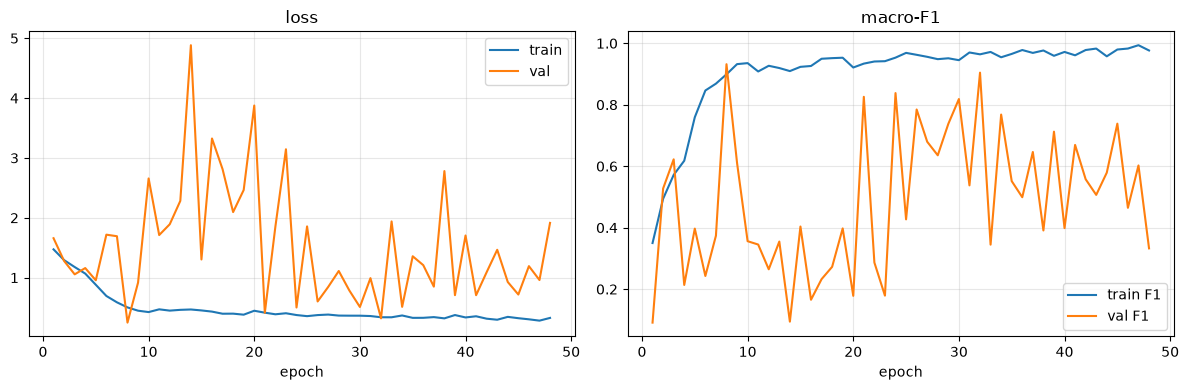

In [14]:
h = np.array(hist, dtype=float)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h[:, 0], h[:, 1], label="train"); ax[0].plot(h[:, 0], h[:, 3], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h[:, 0], h[:, 2], label="train F1"); ax[1].plot(h[:, 0], h[:, 5], label="val F1")
ax[1].set_title("macro-F1"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 11. Evaluate on the held-out test set

A big gap between train and validation curves means memorisation — raise `DROPOUT`, lower
`HIDDEN`, or strengthen the augmentation.

=== test: accuracy 0.9493 | macro-F1 0.9483 (chance = 0.200) ===

              precision    recall  f1-score   support

     Austria      1.000     1.000     1.000        28
      Greece      0.963     0.963     0.963        27
     Hungary      0.931     0.964     0.947        28
     Moldova      0.875     1.000     0.933        28
     Morocco      1.000     0.815     0.898        27

    accuracy                          0.949       138
   macro avg      0.954     0.948     0.948       138
weighted avg      0.953     0.949     0.949       138



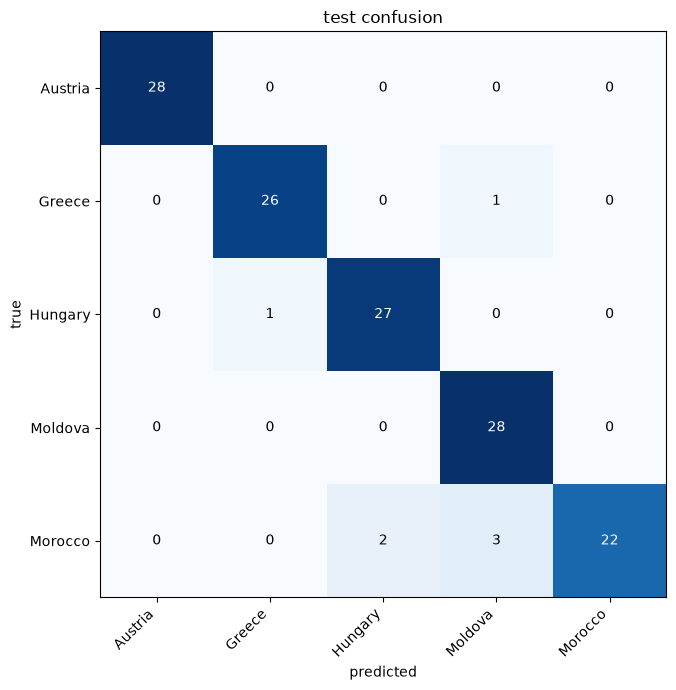

In [15]:
def evaluate(model, indices, title="test"):
    loss, acc, f1, p, t = run_epoch(model, DataLoader(subset(indices, None),
                                                      batch_size=BATCH_SIZE * 2))
    print(f"=== {title}: accuracy {acc:.4f} | macro-F1 {f1:.4f} "
          f"(chance = {1 / NUM_CLASSES:.3f}) ===\n")
    print(classification_report(t, p, target_names=dataset.classes, digits=3,
                                zero_division=0))
    cm = confusion_matrix(t, p, labels=range(NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(1.1 * NUM_CLASSES + 2, 1.0 * NUM_CLASSES + 2))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), dataset.classes, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES), dataset.classes)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.show()
    return acc, f1


test_acc, test_f1 = evaluate(model, te)

## 12. Cross-validation — the number you should actually report

Same reasoning as always: at a few hundred images total, a single test split is noisy. 5-fold
gives a mean ± std instead of one lucky/unlucky number.

In [16]:
RUN_CV = False          # <-- set True when you're ready
CV_FOLDS, CV_EPOCHS = 5, 120

if RUN_CV:
    skf = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED)
    scores, fold_models = [], []
    for k, (tr_k, te_k) in enumerate(skf.split(idx, y_all), 1):
        print(f"\n########## fold {k}/{CV_FOLDS} ##########")
        tr_k, va_k = train_test_split(tr_k, test_size=0.15, stratify=y_all[tr_k],
                                      random_state=SEED)
        m, _, _ = fit(tr_k, va_k, epochs=CV_EPOCHS, verbose=False)
        _, f1 = evaluate(m, te_k, title=f"fold {k}")
        scores.append(f1); fold_models.append(m)
    print(f"\n=== {CV_FOLDS}-fold macro-F1: {np.mean(scores):.4f} "
          f"+- {np.std(scores):.4f} ===")
else:
    fold_models = []
    print("cross-validation skipped (set RUN_CV = True)")

cross-validation skipped (set RUN_CV = True)


## 13. Save and predict on new images

In [17]:
CKPT = "wing_gnn_superpixel.pt"
torch.save({"state_dict": model.state_dict(), "hparams": model.hparams,
            "classes": dataset.classes, "extract_cfg": CFG.to_dict()}, CKPT)
print("saved", CKPT)


def load_model(path=CKPT):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    m = WingGNN(**ck["hparams"]); m.load_state_dict(ck["state_dict"])
    return m.to(DEVICE).eval(), ck["classes"], ExtractConfig(**ck["extract_cfg"])


@torch.no_grad()
def predict(image_path, models=None, classes=None, cfg=None, show=False):
    if models is None:
        m, classes, cfg = load_model(); models = [m]
    g = image_to_graph(image_path, cfg)
    d = Data(x=torch.from_numpy(g["x"]), edge_index=torch.from_numpy(g["edge_index"]),
             edge_attr=torch.from_numpy(g["edge_attr"]))
    d.batch = torch.zeros(d.num_nodes, dtype=torch.long)
    d = d.to(DEVICE)
    probs = torch.stack([F.softmax(m(d), 1) for m in models]).mean(0)[0].cpu().numpy()
    if show:
        show_extraction(image_path, cfg)
    order = np.argsort(-probs)
    return classes[order[0]], float(probs[order[0]]), \
        {classes[i]: round(float(probs[i]), 4) for i in order}


m_, classes_, cfg_ = load_model()
ens = fold_models if fold_models else [m_]        # folds average if you ran CV

test_paths = [dataset.paths[int(i)] for i in te[:5]]
for p in test_paths:
    lab, conf, all_p = predict(p, ens, classes_, cfg_)
    print(f"{Path(p).parent.name:<12} -> {lab:<12} ({conf:.3f})   {all_p}")

saved wing_gnn_superpixel.pt
Austria      -> Austria      (0.934)   {'Austria': 0.9336, 'Moldova': 0.0519, 'Morocco': 0.0068, 'Hungary': 0.005, 'Greece': 0.0026}
Moldova      -> Moldova      (0.980)   {'Moldova': 0.9802, 'Austria': 0.0138, 'Morocco': 0.0044, 'Greece': 0.0012, 'Hungary': 0.0005}
Moldova      -> Moldova      (0.945)   {'Moldova': 0.9452, 'Austria': 0.0376, 'Morocco': 0.0081, 'Greece': 0.0077, 'Hungary': 0.0015}
Austria      -> Austria      (0.964)   {'Austria': 0.9635, 'Moldova': 0.0246, 'Hungary': 0.0052, 'Morocco': 0.0049, 'Greece': 0.0018}
Moldova      -> Moldova      (0.922)   {'Moldova': 0.922, 'Austria': 0.053, 'Morocco': 0.0166, 'Greece': 0.005, 'Hungary': 0.0035}


### Predict on one image with the extraction shown

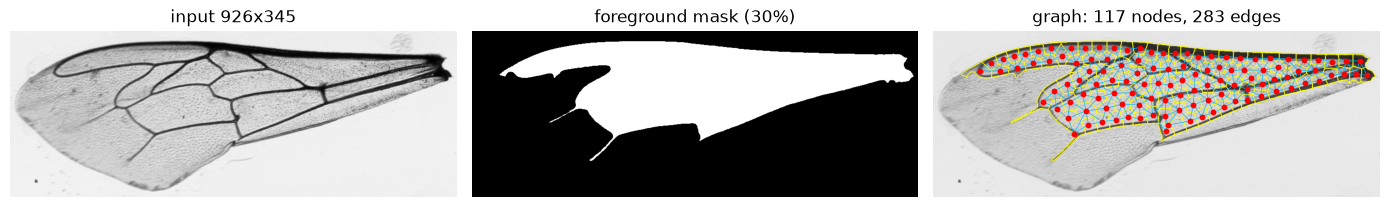

prediction: Austria  confidence 0.934
{'Austria': 0.9336, 'Moldova': 0.0519, 'Morocco': 0.0068, 'Hungary': 0.005, 'Greece': 0.0026}


In [18]:
lab, conf, probs = predict(test_paths[0], ens, classes_, cfg_, show=True)
print(f"prediction: {lab}  confidence {conf:.3f}")
print(probs)

## 14. Adding a 6th region later

1. Create `data/region_F/` and drop the images in.
2. `shutil.rmtree("cache_sp/processed")` — the cache is keyed to the old class list.
3. Re-run from cell 6.

`NUM_CLASSES` comes from `len(dataset.classes)` and is written into the checkpoint. Keep
classes roughly balanced — inverse-frequency class weights help, but a 5:1 imbalance still
hurts.

---

## Superpixel-specific things worth being suspicious of

* **The foreground mask is now doing what the vein mask used to do, and it's checking a
  different assumption.** It assumes the wing is visually distinguishable from its background
  (a different average shade), not that veins are dark lines. If your real photos have the
  wing on a background of *similar* brightness (e.g. a light wing on white paper), Otsu will
  struggle and `foreground_mask` will raise `ExtractionError` or silently pick a bad mask —
  always eyeball cell 5 on real data before trusting it.
* **`compactness` trades off shape-following vs regularity.** Low values let superpixels hug
  vein edges tightly (more informative boundaries, noisier shapes); high values make patches
  more uniform/grid-like (more stable features, less venation detail directly encoded in
  shape). This is the one parameter most worth sweeping on your actual data.
* **This graph has no explicit vein topology.** The model can only use what centroid position,
  patch shape, and patch shade tell it — venation shows up *indirectly*, as edges between
  patches with different shade/eccentricity where a vein crosses. If your bee photos have very
  faint or low-contrast venation, this approach may pick up less signal than an explicitly
  vein-traced graph would; the skeleton-based notebook is the thing to compare against.
* **Same specimen/session leakage risk as before.** If several images per class share a
  specimen or a lighting setup, split by specimen, not by image, or the intensity-based
  features in particular can leak session identity rather than region identity.